## **Hierarchical Clustering:**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [8]:
# Load data
df = pd.read_excel("income.xlsx", names=['name','age','income'])
df.head()

,name,age,income
0,Rob,29,45
1,Andrea,50,80
2,Mohan,35,52
3,Michael,32,41
4,Kory,36,87


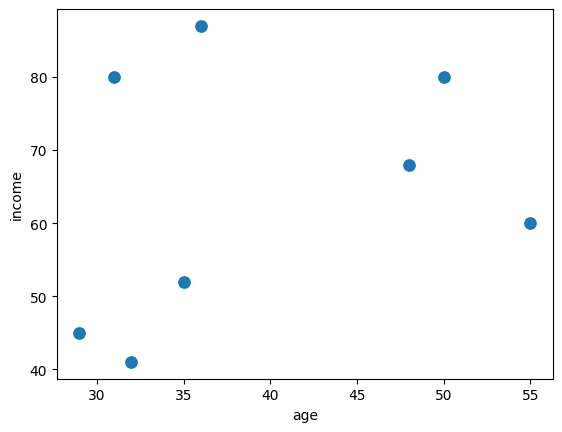

In [17]:
# Plot scatterplot of it
sns.scatterplot(data=df, x = 'age', y = 'income', s = 100)
plt.show()

Let's use Agglomerative Clustering Now.

In [12]:
hc = AgglomerativeClustering(n_clusters=3, linkage='average')
hc.fit(df[['age','income']])
hc.labels_

array([1, 0, 1, 1, 2, 0, 2, 0], dtype=int64)

In [13]:
df['cluster'] = hc.labels_
df.head()

,name,age,income,cluster
0,Rob,29,45,1
1,Andrea,50,80,0
2,Mohan,35,52,1
3,Michael,32,41,1
4,Kory,36,87,2


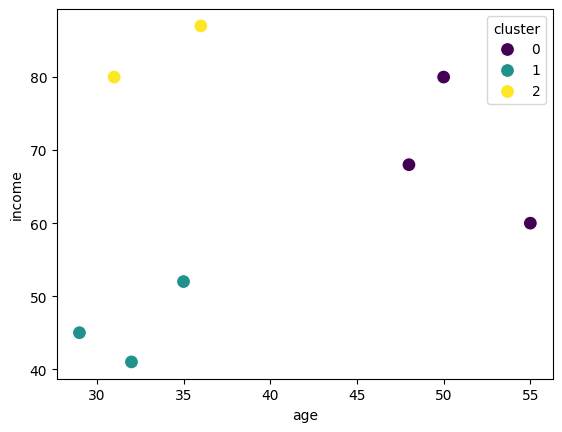

In [16]:
# Let's plot scatter plot again now with the clusters
sns.scatterplot(data=df, x = 'age', y = 'income', s = 100, palette='viridis', hue = 'cluster')
plt.show()

There is other way of forming clusters using scipy libarary's cluster method, Where we can also create dendogram for better visualization.

In [18]:
X = df[['age','income']]
Z = linkage(X, method = 'average') # <-- This is called linkage matrix
Z

array([[ 0.        ,  3.        ,  5.        ,  2.        ],
       [ 4.        ,  6.        ,  8.60232527,  2.        ],
       [ 2.        ,  8.        , 10.31064935,  3.        ],
       [ 5.        ,  7.        , 10.63014581,  2.        ],
       [ 1.        , 11.        , 16.39052659,  3.        ],
       [ 9.        , 12.        , 23.69824661,  5.        ],
       [10.        , 13.        , 33.65863823,  8.        ]])

Here first column represents first record, 2nd columns represents 2nd record and 3rd column reprensents distance between two clusters and last column represents number of clusers between which the linkage operation if performed.

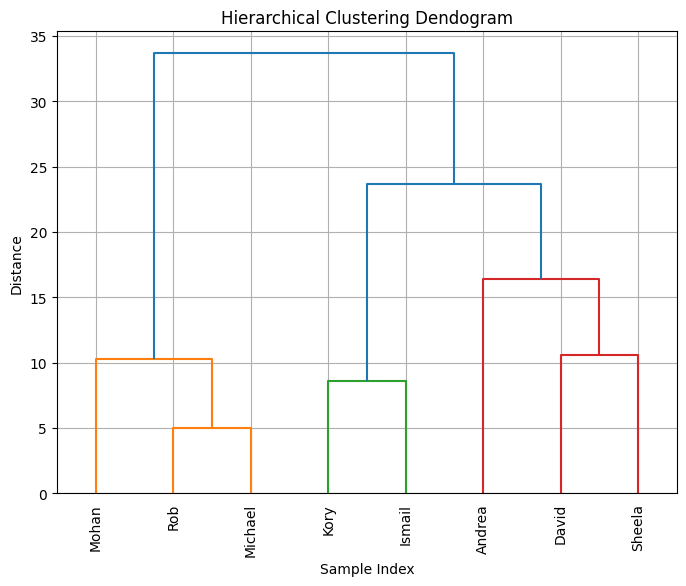

In [19]:
# Plotting the dendogram to understand this linkage matrix clearly
plt.figure(figsize=(8,6))
plt.title('Hierarchical Clustering Dendogram')
dendrogram(Z, labels=df['name'].values, leaf_rotation=90, leaf_font_size=10)
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.grid()
plt.show()

In [20]:
clusters = fcluster(Z, criterion='maxclust', t = 3)
clusters

array([1, 3, 1, 1, 2, 3, 2, 3], dtype=int32)

In [24]:
df['cluster'] = clusters
df.head()

,name,age,income,cluster
0,Rob,29,45,1
1,Andrea,50,80,3
2,Mohan,35,52,1
3,Michael,32,41,1
4,Kory,36,87,2


Plotting the scatterplot again now.

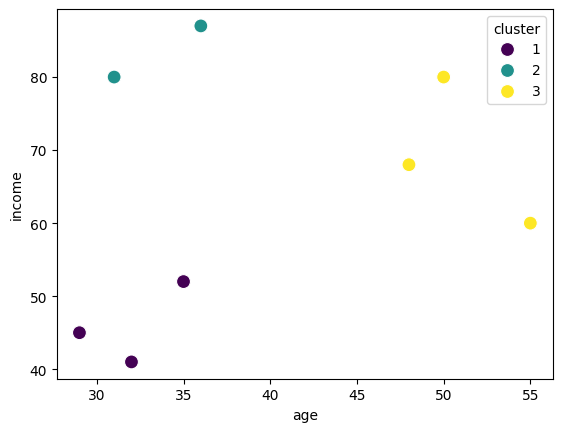

In [25]:
sns.scatterplot(data=df, x = 'age', y = 'income', s = 100, palette='viridis', hue = 'cluster')
plt.show()

Refer the unsupervised learning takeway file for the notes.